# <span style="color:red">  Monthly Data - EW creation, FMB Quantiles (1970 -2024)

#### Import all our packages and functions

In [1]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve().parents[1]
sys.path.append(str(PROJECT_ROOT))
DATA_RAW_DIR = PROJECT_ROOT / "data" / "raw"
DATA_PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"


In [3]:
import importlib
import src.preference_factors.build_datasets as bd
import src.FamaMacBeth.betas as fmb_betas
import src.FamaMacBeth.pipeline as fmb_pipe
import src.FamaMacBeth.cross_sectional_regression as fmb_csr
import src.FamaMacBeth.pricing as fmb_pricing
import src.FamaMacBeth.backtest as fmb_backtest
import src.FamaMacBeth.plots as fmb_plots

# Reload the modules themselves
importlib.reload(bd)
importlib.reload(fmb_betas)
importlib.reload(fmb_pipe)
importlib.reload(fmb_csr)
importlib.reload(fmb_pricing)
importlib.reload(fmb_backtest)
importlib.reload(fmb_plots)


<module 'src.FamaMacBeth.plots' from '/Users/evi/Desktop/Invesco_Research_Project/src/FamaMacBeth/plots.py'>

# <span style="color:red"> Create CSV's for Monthly EW Weights, Beta Contributions, EW returns, Preference Returns, Full preference and factors returns (Raw returns) </span>

In [4]:
merged_df, full_merged_df = bd.build_all_dataset(
    returns_file="sp500_returns_monthly_with_tickers.csv",
    market_caps_file="sp500_market_caps_monthly.csv",
    ff_factors_file="ff_factors_monthly.csv",
    frequency="monthly"
)

# Use raw (non-excess) EW and CW-EW spread
ew = full_merged_df["EW"]
cw_ew = full_merged_df["CW"] - full_merged_df["EW"]

Rolling OLS CAPM:   0%|          | 0/702 [00:00<?, ?it/s]

EBC optimization (parallel):   0%|          | 0/702 [00:00<?, ?it/s]

/Users/evi/Desktop/Invesco_Research_Project/src/preference_factors/build_EBC.py:261: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  weights_rebal = full_weights.resample("Q").last()


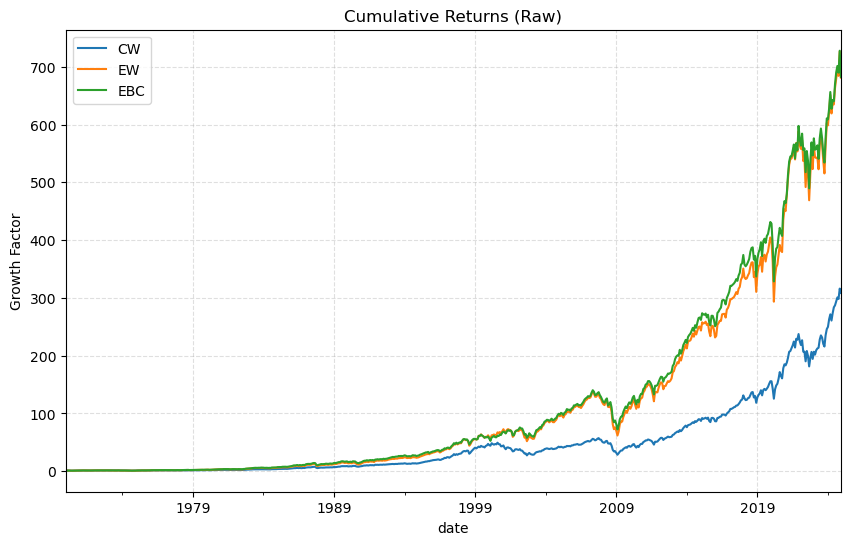

In [5]:
plot_df = full_merged_df[['CW', 'EW', 'EBC']].loc['1970':]
if isinstance(plot_df.index, pd.PeriodIndex):
    plot_df.index = plot_df.index.to_timestamp()
(1 + plot_df).cumprod().plot(figsize=(10, 6))
plt.title("Cumulative Returns (Raw)")
plt.ylabel("Growth Factor")
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()

In [6]:
full_merged_df['MKT'] = full_merged_df['MKT_RF'] + full_merged_df['RF']

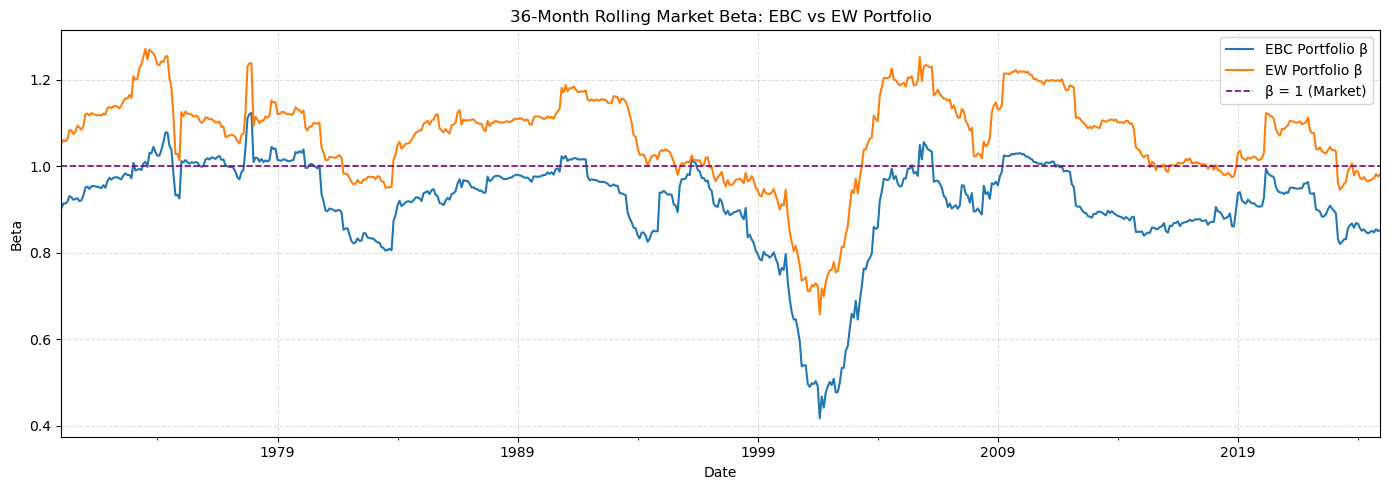


── Rolling Beta Summary ──
         EBC β     EW β
count  660.000  660.000
mean     0.914    1.068
std      0.110    0.104
min      0.418    0.657
25%      0.875    1.007
50%      0.936    1.091
75%      0.981    1.125
max      1.123    1.271


In [7]:
import statsmodels.api as sm

# ── Rolling 36-month Market Beta: EBC vs EW ──
window = 36

ebc_ret = full_merged_df["EBC"].copy()
ew_ret  = full_merged_df["EW"].copy()
mkt     = full_merged_df["MKT"].copy()

# Normalize indices to DatetimeIndex for alignment + plotting
if isinstance(ebc_ret.index, pd.PeriodIndex):
    ebc_ret.index = ebc_ret.index.to_timestamp()
    ew_ret.index  = ew_ret.index.to_timestamp()
if isinstance(mkt.index, pd.PeriodIndex):
    mkt.index = mkt.index.to_timestamp()

combined = pd.DataFrame({
    "EBC": ebc_ret,
    "EW":  ew_ret,
    "MKT": mkt
}).dropna()

beta_ebc, beta_ew, dates = [], [], []

for i in range(window, len(combined) + 1):
    w  = combined.iloc[i - window:i]
    X  = sm.add_constant(w["MKT"])
    try:
        beta_ebc.append(sm.OLS(w["EBC"], X).fit().params["MKT"])
        beta_ew.append( sm.OLS(w["EW"],  X).fit().params["MKT"])
    except Exception:
        beta_ebc.append(np.nan)
        beta_ew.append(np.nan)
    dates.append(combined.index[i - 1])

beta_df = pd.DataFrame({"EBC β": beta_ebc, "EW β": beta_ew}, index=dates)

plot_beta = beta_df.loc['1970':]

plt.figure(figsize=(14, 5))
plot_beta["EBC β"].plot(linewidth=1.5, label="EBC Portfolio β", color="tab:blue")
plot_beta["EW β"].plot( linewidth=1.5, label="EW Portfolio β",  color="tab:orange")
plt.axhline(1.0, color="purple", linestyle="--", linewidth=1.2, label="β = 1 (Market)")
plt.title("36-Month Rolling Market Beta: EBC vs EW Portfolio")
plt.ylabel("Beta")
plt.xlabel("Date")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

print("\n── Rolling Beta Summary ──")
print(plot_beta.describe().round(3))

# <span style="color:red"> Get rolling betas for the two focus portfolios EW and CW - EW </span>

#### create factor returns

In [8]:
ew = ew.to_frame(name="EW")
cw_ew = cw_ew.to_frame(name="CW-EW")

# Convert to timestamp to match asset_returns index
ew.index = ew.index.to_timestamp()
cw_ew.index = cw_ew.index.to_timestamp()

factor_returns = pd.concat([ew, cw_ew], axis=1).dropna()

#### get asset returns (raw, no RF subtraction)

In [9]:
asset_returns, caps_df, ff_factors = fmb_pipe.load_monthly_inputs(DATA_RAW_DIR, excess= False)

#### compute rolling betas for EW and CW-EW

In [10]:
betas_ew = fmb_betas.compute_rolling_betas(asset_returns, ew, rolling_window=36, min_obs=10)
betas_cw_ew = fmb_betas.compute_rolling_betas(asset_returns, cw_ew, rolling_window=36, min_obs=10)

Estimating rolling betas: 100%|██████████| 702/702 [00:32<00:00, 21.89it/s]
/Users/evi/Desktop/Invesco_Research_Project/src/FamaMacBeth/betas.py:74: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  stacked = betas_df.stack(dropna=True)
Estimating rolling betas: 100%|██████████| 702/702 [00:25<00:00, 27.87it/s]
/Users/evi/Desktop/Invesco_Research_Project/src/FamaMacBeth/betas.py:74: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  stacked = betas_df.stack(dropna=True)


# <span style="color:red"> Equal Weighted Portfolio Plots --> Run full factor pipeline --> Two factor regressions FMB </span>

In [11]:
start_date = "1969-10-01"

## Filter all returns to match start date

In [12]:
asset_returns_trimmed = asset_returns.loc[start_date:]
caps_df_trimmed = caps_df.loc[start_date:]
factor_returns_trimmed = factor_returns.loc[start_date:]
betas_ew_trimmed = betas_ew.loc[start_date:]
betas_cw_ew_trimmed = betas_cw_ew.loc[start_date:]

In [13]:
n_q1, n_q2 = 3,3

In [14]:
#3,3

rename_map = {
    "Q1_Q1": "EW_High_Pref_High",
    "Q1_Q2": "EW_High_Pref_Mid",
    "Q1_Q3": "EW_High_Pref_Low",
    "Q2_Q1": "EW_Mid_Pref_High",
    "Q2_Q2": "EW_Mid_Pref_Mid",
    "Q2_Q3": "EW_Mid_Pref_Low",
    "Q3_Q1": "EW_Low_Pref_High",
    "Q3_Q2": "EW_Low_Pref_Mid",
    "Q3_Q3": "EW_Low_Pref_Low",
}




In [15]:
if isinstance(full_merged_df.index, pd.PeriodIndex):
    full_merged_df.index = full_merged_df.index.to_timestamp(how="start")

In [16]:
ew_results = fmb_pipe.run_full_factor_pipeline(
    beta_EBC_df = betas_ew_trimmed,
    beta_CW_EBC_df=betas_cw_ew_trimmed,
    returns_df=asset_returns_trimmed,
    caps_df = caps_df_trimmed,
    EBC_returns_df=factor_returns_trimmed["EW"],
    Cap_EBC_returns_df=factor_returns_trimmed["CW-EW"],
    cap_weights=False,
    n_q1 = n_q1,
    n_q2 = n_q2,
    frequency = 'monthly',
    formation_frequency='quarterly',
    min_assets_per_cell=3,
    f1_name="EW",
    f2_name="CW-EW"
)

ew_results["mean_grid"]*12

Q1 buckets:   0%|          | 0/3 [00:00<?, ?it/s]

,1,2,3
1,0.148223,0.146362,0.150978
2,0.133291,0.138197,0.136598
3,0.117654,0.124769,0.135798


In [17]:
rename_map = {
    "Q1_Q1": "EW_High_Pref_High",
    "Q1_Q2": "EW_High_Pref_Mid",
    "Q1_Q3": "EW_High_Pref_Low",
    "Q2_Q1": "EW_Mid_Pref_High",
    "Q2_Q2": "EW_Mid_Pref_Mid",
    "Q2_Q3": "EW_Mid_Pref_Low",
    "Q3_Q1": "EW_Low_Pref_High",
    "Q3_Q2": "EW_Low_Pref_Mid",
    "Q3_Q3": "EW_Low_Pref_Low",
}

ew_portrets_raw = ew_results['portrets_wide'].copy()
ew_results['portrets_wide'] = ew_results['portrets_wide'].rename(columns=rename_map)


In [18]:
selected_columns = ['CW',
                    'EW_High_Pref_High', 'EW_High_Pref_Mid', 'EW_High_Pref_Low',
                    'EW_Mid_Pref_High', 'EW_Mid_Pref_Mid', 'EW_Mid_Pref_Low',
                    'EW_Low_Pref_High', 'EW_Low_Pref_Mid', 'EW_Low_Pref_Low']

In [19]:
ew_complete_df = full_merged_df.join(
    ew_results['portrets_wide'],
    how="inner"
)

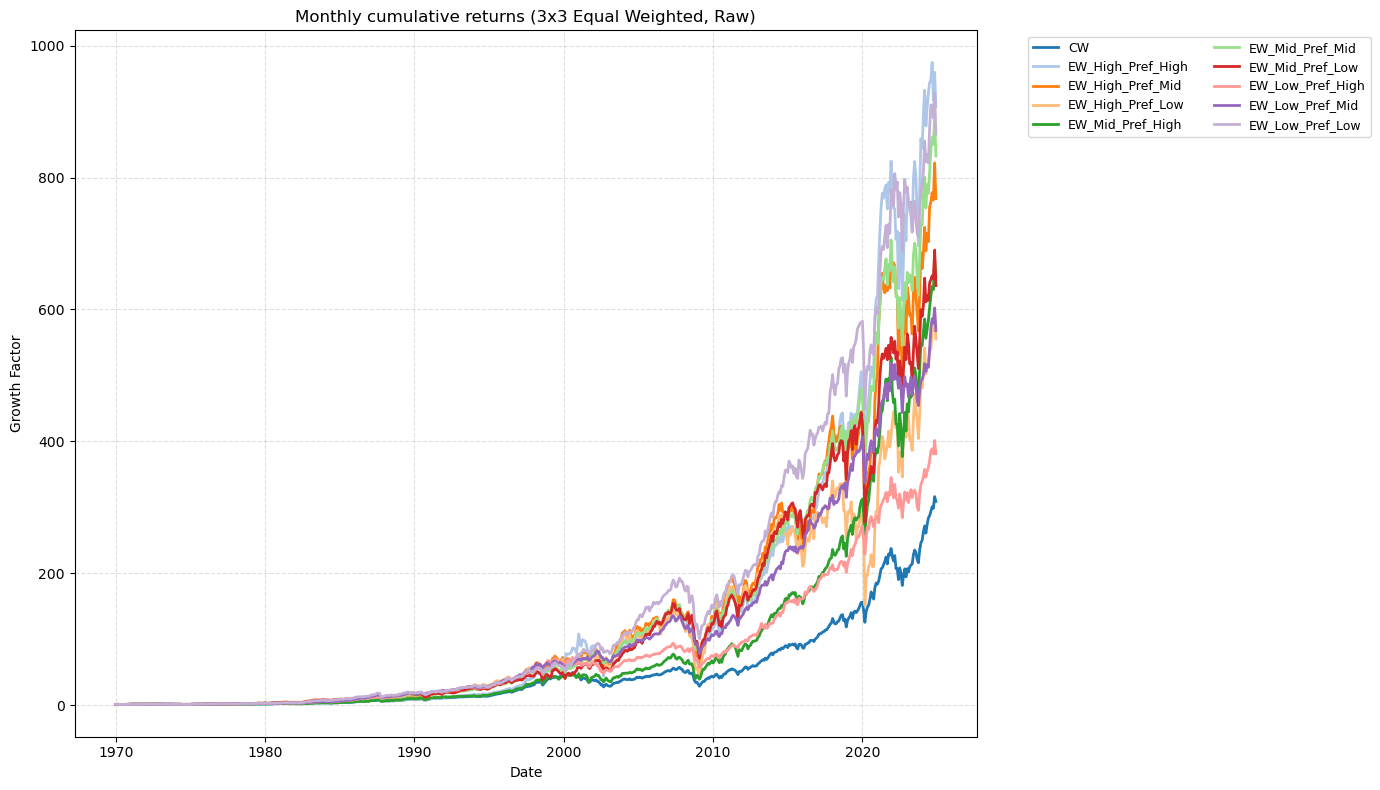

In [20]:
fmb_plots.plot_cum_returns(ew_complete_df[selected_columns],
                                title=f"Monthly cumulative returns ({n_q1}x{n_q2} Equal Weighted, Raw)", log=False)

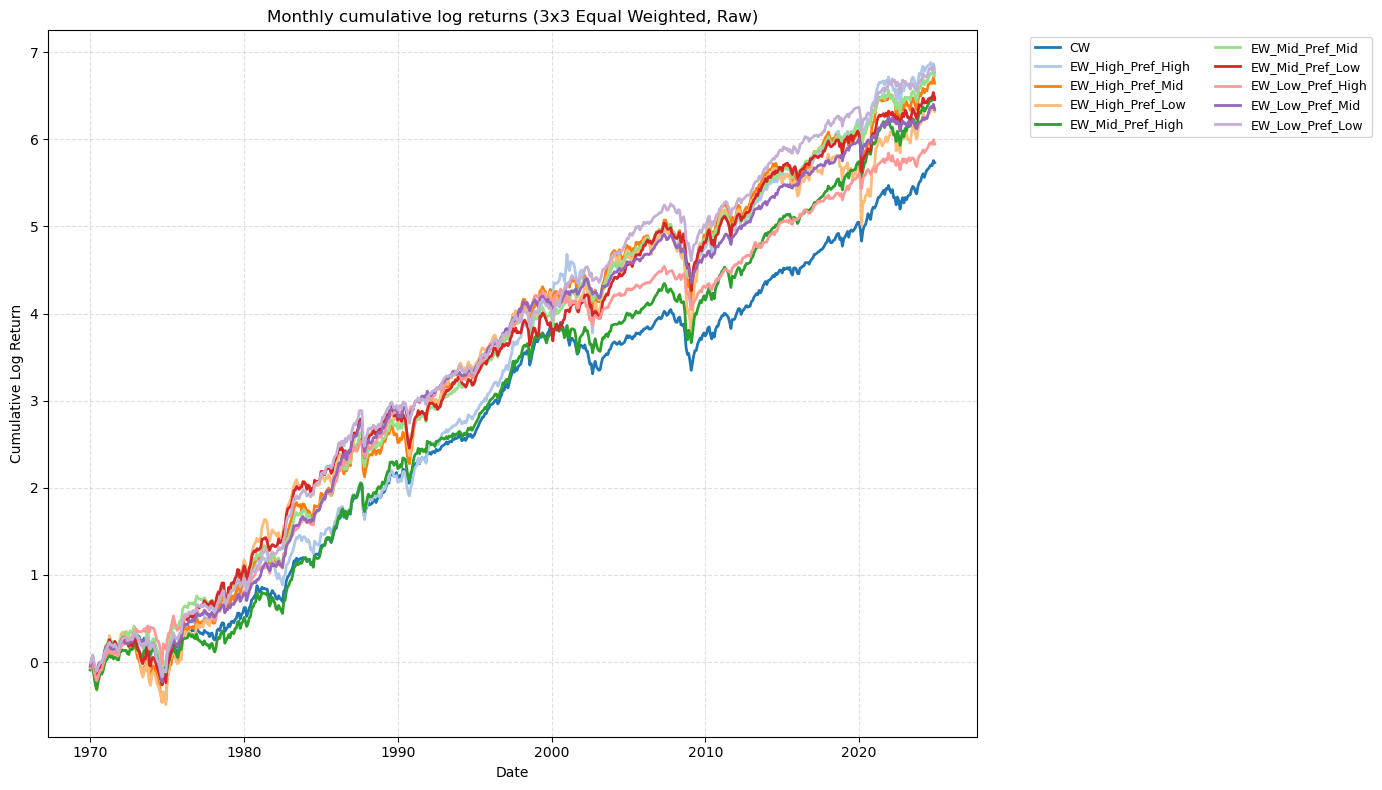

In [21]:
fmb_plots.plot_cum_returns(ew_complete_df[selected_columns],
                                title=f"Monthly cumulative log returns ({n_q1}x{n_q2} Equal Weighted, Raw)",log = True)

In [22]:
monthly_ew_quantile_returns = ew_complete_df[selected_columns]

In [23]:
ew_portrets_raw

,Q1_Q1,Q1_Q2,Q1_Q3,Q2_Q1,Q2_Q2,Q2_Q3,Q3_Q1,Q3_Q2,Q3_Q3
date,,,,,,,,,
1970-01-01,-0.088577,-0.052556,-0.059371,-0.084496,-0.061924,-0.040140,-0.064652,-0.043835,-0.012122
1970-02-01,0.083323,0.099994,0.120036,0.043807,0.061329,0.070606,0.058876,0.082422,0.044278
1970-03-01,-0.009082,-0.005399,-0.006746,0.003689,0.013971,0.023608,-0.001031,0.010605,0.051202
1970-04-01,-0.124838,-0.146129,-0.151766,-0.118923,-0.080879,-0.098839,-0.084343,-0.074648,-0.082221
1970-05-01,-0.084487,-0.091585,-0.102253,-0.086527,-0.071793,-0.076026,-0.064228,-0.052196,-0.058585
...,...,...,...,...,...,...,...,...,...
2024-08-01,0.004942,0.010499,-0.003104,0.029555,0.041171,0.008092,0.039704,0.060378,0.039353
2024-09-01,0.027617,0.018211,0.051274,0.022627,0.024280,0.008984,0.007645,0.023628,0.000562
2024-10-01,-0.059104,-0.014397,0.000127,-0.007489,-0.011735,-0.006729,-0.019047,-0.011144,-0.021731


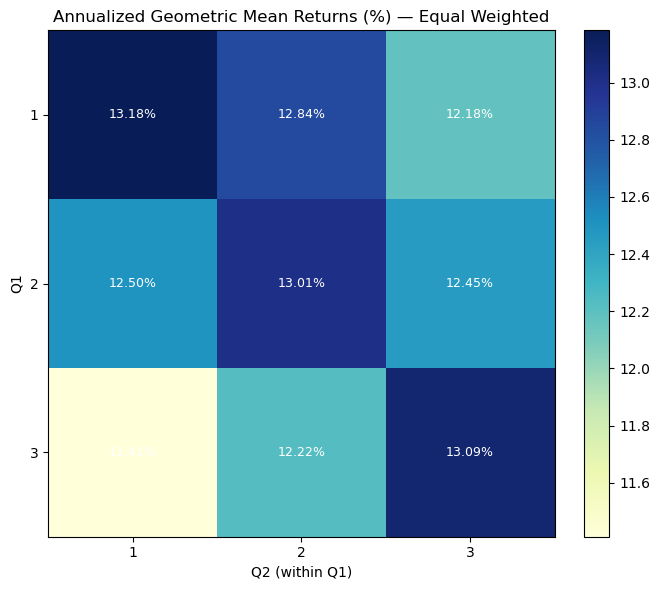

In [24]:
# True geometric mean grid (annualized as (1+geo_monthly)^12 − 1)
ew_actual_mean_grid = fmb_plots.plot_mean_grid_new(
    ew_results["mean_grid"], annualize=True, frequency='monthly', cw=False, geometric=True,
    portrets_wide=ew_portrets_raw
)

In [25]:
ew_actual_mean_grid

,1,2,3
1,13.182491,12.839740,12.176223
2,12.496897,13.006253,12.453360
3,11.411328,12.222089,13.086071


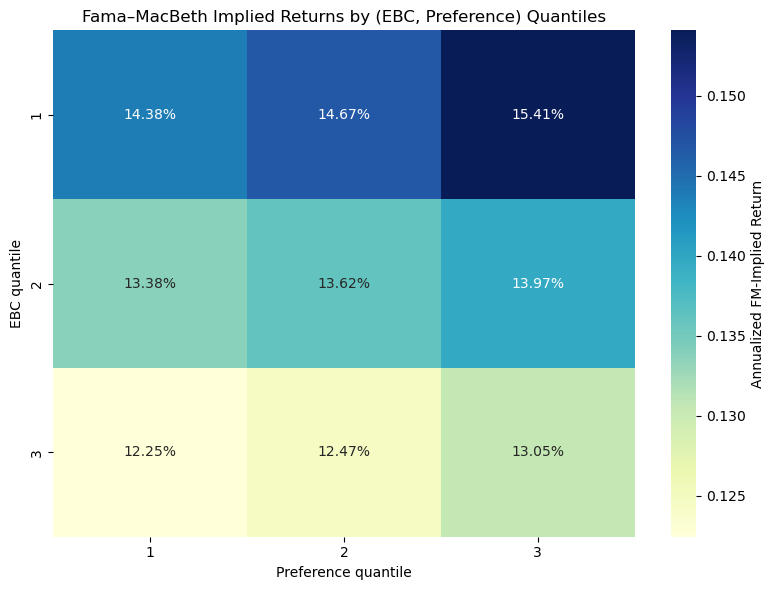

In [26]:
ew_implied_mean_grid = fmb_plots.plot_expected_return_grid(ew_results["pricing"], ew_results["fm_table"], n_q1, n_q2)

## Turnover

In [27]:
# ── Portfolio Turnover (Cap Weighted) ─────────────────────────────────────
members_cw = ew_results["members"].copy()
m = members_cw.reset_index()
m['period'] = m['date'].dt.to_period('Q')
first_date_per_period = m.groupby('period')['date'].min()
m_first = m[m['date'].isin(first_date_per_period.values)]

# Dynamic portfolio names derived from portrets_wide column order
_cw_cols = list(ew_results['portrets_wide'].columns)
portfolio_names = {
    (q1, q2): _cw_cols[(q1 - 1) * n_q2 + (q2 - 1)]
    for q1 in range(1, n_q1 + 1)
    for q2 in range(1, n_q2 + 1)
}

In [28]:
period = start_date[:4] + '_2024'

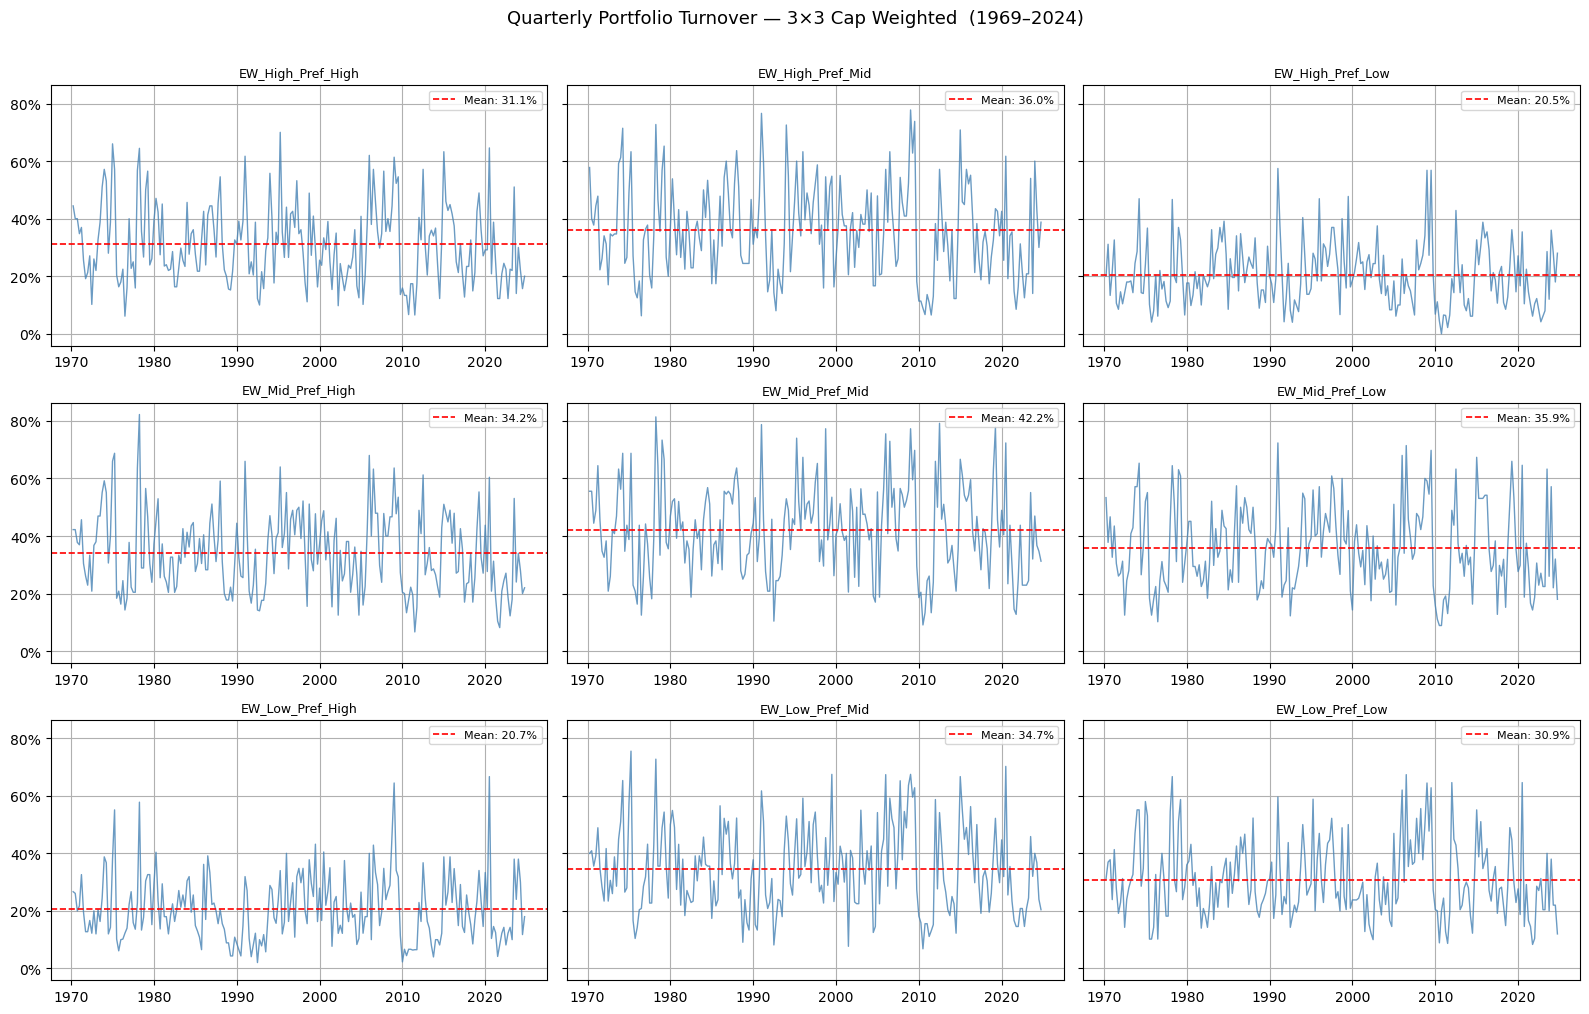

In [29]:
turnover_dict_cw = {}

for q1 in range(1, n_q1 + 1):
    for q2 in range(1, n_q2 + 1):
        cell_data = m_first[(m_first['q1'] == q1) & (m_first['q2'] == q2)]
        by_period = cell_data.groupby('period')['ticker'].apply(set)

        turnovers, dates_out = [], []
        prev_set = None
        for period_key, tickers in by_period.items():
            if prev_set is not None:
                left = prev_set - tickers
                turnovers.append(len(left) / len(prev_set) if prev_set else np.nan)
                dates_out.append(period_key.to_timestamp())
            prev_set = tickers

        turnover_dict_cw[portfolio_names[(q1, q2)]] = pd.Series(turnovers, index=dates_out)

turnover_cw = pd.DataFrame(turnover_dict_cw)

# ── Plot: 3x3 grid ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 3, figsize=(16, 10), sharey=True)
axes_flat = axes.flatten()

for ax, col in zip(axes_flat, turnover_cw.columns):
    avg = turnover_cw[col].mean()
    ax.plot(turnover_cw.index, turnover_cw[col], color='steelblue', linewidth=1, alpha=0.8)
    ax.axhline(avg, color='red', linestyle='--', linewidth=1.2, label=f"Mean: {avg:.1%}")
    ax.set_title(col, fontsize=9)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
    ax.legend(fontsize=8)
    ax.grid(True)

plt.suptitle(
    f"Quarterly Portfolio Turnover — {n_q1}×{n_q2} Cap Weighted  ({period.replace('_', '–')})",
    fontsize=13, y=1.01
)
plt.tight_layout()
plt.show()



In [30]:

# ── Average turnover summary table ─────────────────────────────────────────
avg_to_cw = pd.DataFrame({
    "Avg Quarterly Turnover": turnover_cw.mean(),
    "Annualized Turnover":    turnover_cw.mean() * 4,
}).round(4)

print("Average Turnover by Portfolio Cell (Cap Weighted):")
display(avg_to_cw)

Average Turnover by Portfolio Cell (Cap Weighted):


,Avg Quarterly Turnover,Annualized Turnover
EW_High_Pref_High,0.3108,1.2433
EW_High_Pref_Mid,0.3596,1.4383
EW_High_Pref_Low,0.2050,0.8200
EW_Mid_Pref_High,0.3419,1.3674
EW_Mid_Pref_Mid,0.4219,1.6875
EW_Mid_Pref_Low,0.3594,1.4377
EW_Low_Pref_High,0.2068,0.8273
EW_Low_Pref_Mid,0.3465,1.3861
EW_Low_Pref_Low,0.3088,1.2351


# <span style="color:red"> Transaction Costs — Quantile Portfolios </span>

**Formula (Invesco):** `TC = 2 × Turnover × 0.0005`

| Term | Meaning |
|---|---|
| `Turnover` | Fraction of holdings that *exit* a cell at each quarterly rebalancing |
| `0.0005` | One-way cost per dollar traded (5 bps: bid-ask spread + execution) |
| `× 2` | Round-trip: pay the spread to **sell** exiting stocks **and** to **buy** replacements |

Rebalancing is **quarterly**, so the cost is a one-time deduction applied in the **first month** of each new quarter. Non-rebalancing months are unaffected.

> To change the cost assumption, adjust `ONE_WAY_COST` below.

In [31]:
ONE_WAY_COST = 0.0005  # bps per side — change here to update everything below

# ── Step 1: EW turnover (from member assignments) ─────────────────────────
members_ew = ew_results["members"].copy()
m_ew = members_ew.reset_index()
m_ew['period'] = m_ew['date'].dt.to_period('Q')
first_date_per_period_ew = m_ew.groupby('period')['date'].min()
m_ew_first = m_ew[m_ew['date'].isin(first_date_per_period_ew.values)]

# Dynamic names derived from portrets_wide column order
_ew_cols = list(ew_results['portrets_wide'].columns)
portfolio_names_ew = {
    (q1, q2): _ew_cols[(q1 - 1) * n_q2 + (q2 - 1)]
    for q1 in range(1, n_q1 + 1)
    for q2 in range(1, n_q2 + 1)
}

turnover_dict_ew = {}
for q1 in range(1, n_q1 + 1):
    for q2 in range(1, n_q2 + 1):
        cell_data = m_ew_first[(m_ew_first['q1'] == q1) & (m_ew_first['q2'] == q2)]
        by_period = cell_data.groupby('period')['ticker'].apply(set)
        turnovers, dates_out = [], []
        prev_set = None
        for period_key, tickers in by_period.items():
            if prev_set is not None:
                left = prev_set - tickers
                turnovers.append(len(left) / len(prev_set) if prev_set else np.nan)
                dates_out.append(period_key.to_timestamp())
            prev_set = tickers
        turnover_dict_ew[portfolio_names_ew[(q1, q2)]] = pd.Series(turnovers, index=dates_out)

turnover_ew = pd.DataFrame(turnover_dict_ew)
turnover_ew_q = turnover_ew.copy()
turnover_ew_q.index = pd.DatetimeIndex(turnover_ew_q.index).to_period('Q')

# ── Step 2: Helper — map quarterly TC to first monthly return of each quarter
def build_tc_monthly(gross_df, turnover_q_df, one_way_cost):
    monthly_quarters = gross_df.index.to_period('Q')
    first_month_of_quarter = {}
    for date, q in zip(gross_df.index, monthly_quarters):
        if q not in first_month_of_quarter:
            first_month_of_quarter[q] = date
    tc = pd.DataFrame(0.0, index=gross_df.index, columns=gross_df.columns)
    for col in turnover_q_df.columns:
        if col not in tc.columns:
            continue
        for q_period, to_val in turnover_q_df[col].items():
            if q_period in first_month_of_quarter and not np.isnan(to_val):
                tc.loc[first_month_of_quarter[q_period], col] = 2 * to_val * one_way_cost
    return tc

# ── Step 3: Apply TC to both EW and CW portfolios ─────────────────────────
ew_gross = ew_results['portrets_wide'].copy()

ew_tc = build_tc_monthly(ew_gross, turnover_ew_q, ONE_WAY_COST)

ew_net = ew_gross - ew_tc

print(f"One-way cost : {ONE_WAY_COST*10_000:.1f} bps  |  Round-trip per 100% turnover: {2*ONE_WAY_COST*100:.2f}%")
print(f"\nMean quarterly TC per EW portfolio (bps):")
print((ew_tc[ew_tc > 0].mean() * 10_000).round(2).to_string())

One-way cost : 5.0 bps  |  Round-trip per 100% turnover: 0.10%

Mean quarterly TC per EW portfolio (bps):
EW_High_Pref_High    3.11
EW_High_Pref_Mid     3.60
EW_High_Pref_Low     2.06
EW_Mid_Pref_High     3.42
EW_Mid_Pref_Mid      4.22
EW_Mid_Pref_Low      3.59
EW_Low_Pref_High     2.07
EW_Low_Pref_Mid      3.47
EW_Low_Pref_Low      3.09


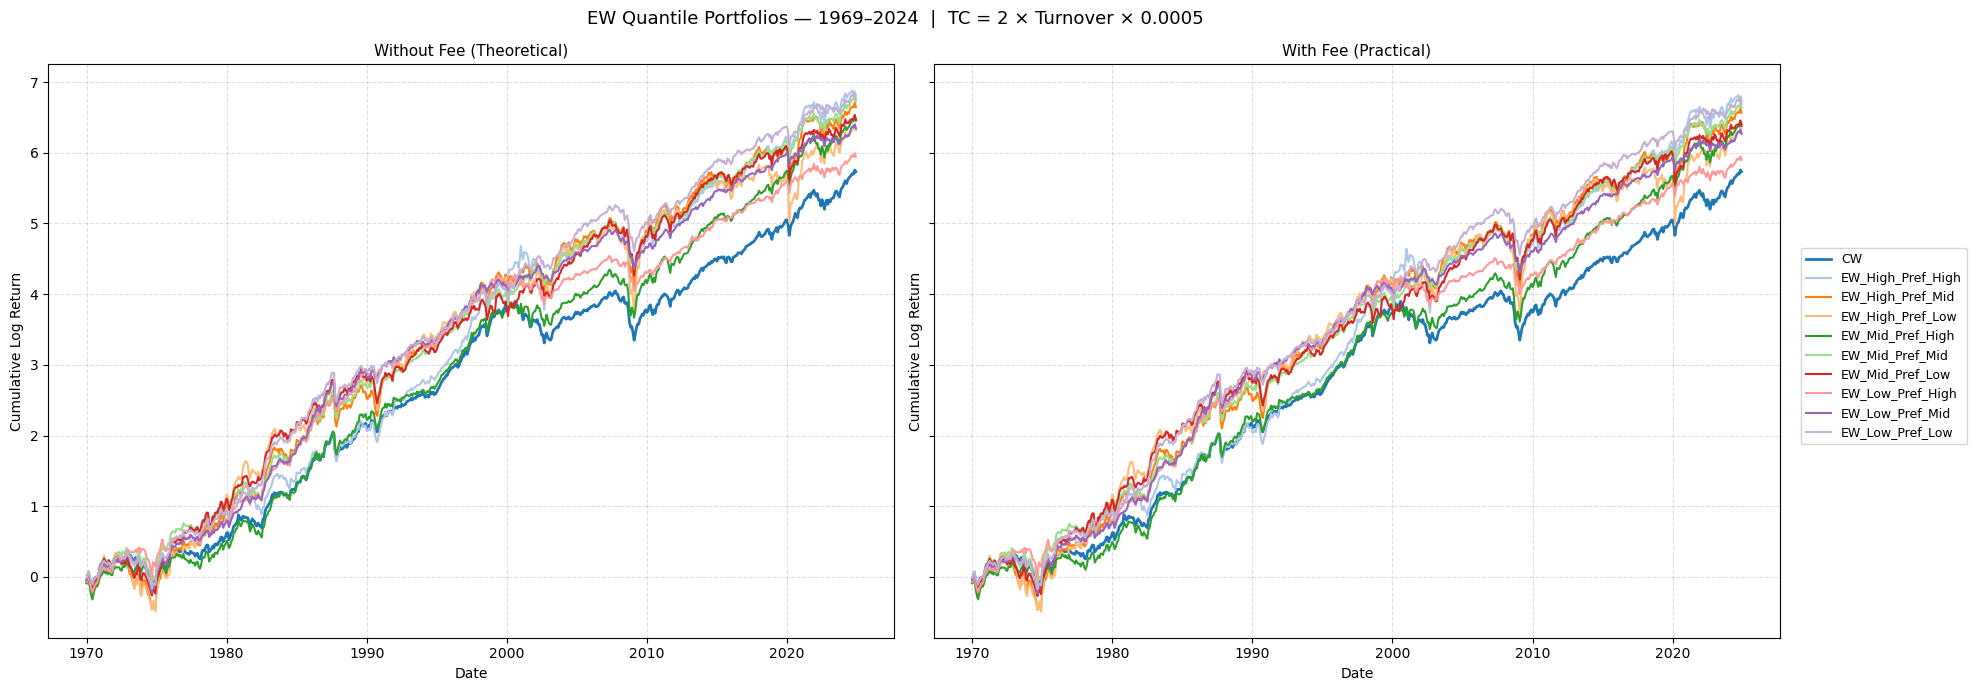

In [32]:
# ── Gross vs Net side-by-side (log cumulative returns) ────────────────────
# Left  = Without fee (theoretical)  |  Right = With fee (practical)

palette = plt.cm.tab20.colors
bench_color = palette[0]
port_colors = palette[1:10]

port_cols = list(ew_gross.columns)

bench = ew_complete_df['CW'].dropna()
bench_logcum = np.log1p(bench).cumsum()

def plot_gross_net_side_by_side(gross_df, net_df, bench_logcum, suptitle):
    fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=True)

    for ax, df, subtitle in zip(axes,
                                [gross_df, net_df],
                                ["Without Fee (Theoretical)", "With Fee (Practical)"]):
        ax.plot(bench_logcum.index, bench_logcum.values,
                color=bench_color, linewidth=2, label='CW')
        for col, color in zip(port_cols, port_colors):
            lc = np.log1p(df[col].dropna()).cumsum()
            ax.plot(lc.index, lc.values, color=color, linewidth=1.5, label=col)
        ax.set_title(subtitle, fontsize=11)
        ax.set_xlabel("Date")
        ax.set_ylabel("Cumulative Log Return")
        ax.grid(True, linestyle='--', alpha=0.4)

    # Single shared legend to the right of both panels
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, ncol=1, fontsize=9,
               bbox_to_anchor=(1.0, 0.5), loc='center left')
    fig.suptitle(suptitle, fontsize=13)
    plt.tight_layout()
    plt.show()


plot_gross_net_side_by_side(
    ew_gross, ew_net, bench_logcum,
    f"EW Quantile Portfolios — {period.replace('_','–')}  |  TC = 2 × Turnover × {ONE_WAY_COST}"
)

In [33]:
# ── Summary: Gross vs Net annualized geometric mean returns ───────────────
def tc_summary(gross_df, net_df, tc_df, label):
    rows = []
    for col in gross_df.columns:
        ann_gross = (1 + np.expm1(np.log1p(gross_df[col].dropna()).mean())) ** 12 - 1
        ann_net   = (1 + np.expm1(np.log1p(net_df[col].dropna()).mean())) ** 12 - 1
        avg_ann_tc = tc_df[col][tc_df[col] > 0].mean() * 4  # 4 quarters/year
        rows.append({
            "Portfolio": col.replace("EBC_", "").replace("_", " "),
            "Gross Ann.": f"{ann_gross:.2%}",
            "Net Ann.":   f"{ann_net:.2%}",
            "TC Drag (bps)": f"{(ann_gross - ann_net)*10_000:.1f}",
            "Avg Ann. TC (bps)": f"{avg_ann_tc*10_000:.1f}",
        })
    df = pd.DataFrame(rows).set_index("Portfolio")
    print(f"\n{'─'*60}")
    print(f"  {label}  |  {ONE_WAY_COST*10_000:.0f}bps/side  |  Formula: 2 × Turnover × {ONE_WAY_COST}")
    print(f"{'─'*60}")
    display(df)

tc_summary(ew_gross, ew_net, ew_tc, "EW Quantile Portfolios")


────────────────────────────────────────────────────────────
  EW Quantile Portfolios  |  5bps/side  |  Formula: 2 × Turnover × 0.0005
────────────────────────────────────────────────────────────


,Gross Ann.,Net Ann.,TC Drag (bps),Avg Ann. TC (bps)
Portfolio,,,,
EW High Pref High,13.18%,13.04%,13.8,12.4
EW High Pref Mid,12.84%,12.68%,16.0,14.4
EW High Pref Low,12.18%,12.09%,9.1,8.2
EW Mid Pref High,12.50%,12.35%,15.1,13.7
EW Mid Pref Mid,13.01%,12.82%,18.8,16.9
EW Mid Pref Low,12.45%,12.29%,15.9,14.4
EW Low Pref High,11.41%,11.32%,9.1,8.3
EW Low Pref Mid,12.22%,12.07%,15.3,13.9
EW Low Pref Low,13.09%,12.95%,13.8,12.4


In [34]:
'''
save_dir = DATA_PROCESSED_DIR / 'monthly'
ew_results['portrets_wide'].to_csv(save_dir / f"monthly_{period}_ew_3x3_ew_quantile_returns.csv")
print(f"Saved: monthly_{period}_ew_3x3_ew_quantile_returns.csv")
'''

Saved: monthly_1969_2024_ew_3x3_ew_quantile_returns.csv
